# Hyperparameter Scaling Analysis of Deep Neural Networks
**Author:** Nikolai Kruse | **Date:** August 2025 | **Target:** EMNIST Dataset

## 1. Introduction & Motivation
While deep learning models are often treated as black-box optimizers, their training dynamics and performance scaling can be rigorously analyzed using methods akin to statistical mechanics and complex systems. 

In this project, I systematically investigate the scaling behavior of a Multi-Layer Perceptron (MLP) trained on the EMNIST dataset. Instead of merely searching for an optimal configuration, this study focuses on:
1. **Capacity Scaling:** How does the degrees of freedom (network width/depth) relate to the generalization error?
2. **Training Dynamics:** How does the stochastic noise in Mini-Batch Gradient Descent affect convergence rates and wall-clock time?
3. **Non-linearities:** The impact of activation functions on the loss landscape.

All training runs were executed on a GPU cluster and the results were serialized. This notebook serves as the analytical showcase of the extracted metrics.

In [1]:
import pickle
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

# Import custom modules from the src/ directory
import sys
sys.path.append("..")
from src.data import load_emnist_data, get_dataset_info
from src.visualization import (
    plot_measurement, plot_batchsize, plot_time, 
    plot_activations, plot_confusion_matrix
)

# Set base paths
RESULTS_DIR = Path("../results")
FIGURES_DIR = Path("../figures")

# Load Dataset Info for the Confusion Matrix
num_classes, emnist_symbols = get_dataset_info("balanced")

## 2. Network Capacity: Width Scaling and Saturation
First, we analyze the scaling of the test accuracy as a function of the hidden layer width $N$ (where Width $= 2^n$). In physics terms, increasing the width increases the model's degrees of freedom.

We expect a transition from an **under-parameterized regime** (where the model lacks capacity to resolve the data manifold) to an **over-parameterized regime** (where performance saturates).

I0000 00:00:1791210754.474964 3825473 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1791210756.678486 3825473 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 479 MB memory:  -> device: 0, name: Tesla V100S-PCIE-32GB, pci bus id: 0000:01:00.0, compute capability: 7.0
I0000 00:00:1791210756.679406 3825473 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 30822 MB memory:  -> device: 1, name: Tesla V100S-PCIE-32GB, pci bus id: 0000:21:00.0, compute capability: 7.0
I0000 00:00:1791210756.680131 3825473 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:2 with 30822 MB memory:  -> device: 2, name: Tesla V100S-PCIE-32GB, pci bus id: 0000:41:00.0, compute cap

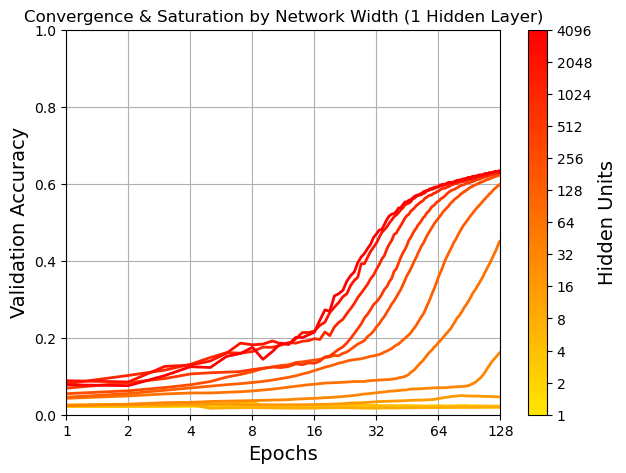

In [2]:
# Load scaling data for 1-Layer Network
with open(RESULTS_DIR / "exp01_width_scaling_1L.pkl", "rb") as f:
    data_1L = pickle.load(f)

# Plot Validation Accuracy over Epochs for different widths
plot_measurement(
    num_networks=13,
    num_epochs=128,
    network_logs=data_1L[0],
    measurement="val_accuracy",
    scale="log",
    y_label="Validation Accuracy",
    c_label="Hidden Units",
    title="Convergence & Saturation by Network Width (1 Hidden Layer)",
    filename="Capacity_Scaling_1L",
    output_dir=FIGURES_DIR
)

**Observation:** The accuracy scales logarithmically with network width up to a critical threshold (around $2^8 = 256$ neurons). Beyond this point, adding more degrees of freedom yields diminishing returns, indicating that the model capacity has saturated relative to the complexity of the EMNIST dataset.

## 3. Stochastic Dynamics: Batch Size Scaling and Power Laws
Mini-batch gradient descent introduces stochastic noise into the optimization process. A smaller batch size means higher variance in the gradient estimator. Here, we analyze the trade-off between computational efficiency (time per epoch) and the batch size.

We fit a **power law** $T \propto B^{-\alpha}$ to the training time per epoch $T$ as a function of the batch size $B$.

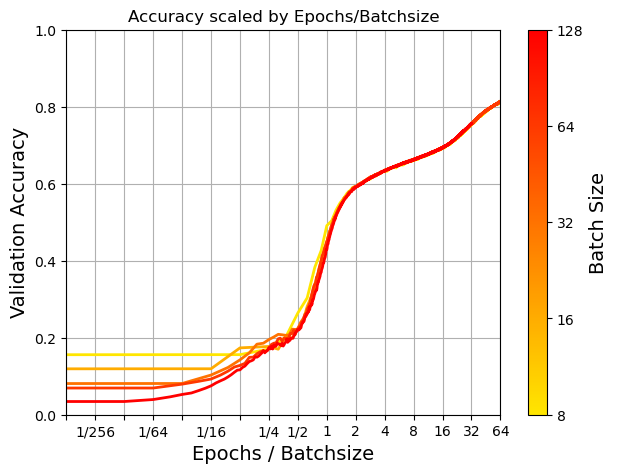

In [3]:
# Load batch size variation data
with open(RESULTS_DIR / "exp02a_batchsize_scaling.pkl", "rb") as f:
    batch_data_1 = pickle.load(f)
with open(RESULTS_DIR / "exp02b_batchsize_scaling.pkl", "rb") as f:
    batch_data_2 = pickle.load(f)

# Merge datasets
combined_logs = batch_data_2[0] + batch_data_1[0]

# Visualize Batch Size Efficiency
plot_batchsize(
    num_networks=5,
    num_epochs=128,
    network_logs=combined_logs,
    measurement="val_accuracy",
    scale="log",
    y_label="Validation Accuracy",
    c_label="Batch Size",
    title="Accuracy scaled by Epochs/Batchsize",
    filename="Batchsize_Scaling",
    min_network=3,
    output_dir=FIGURES_DIR
)

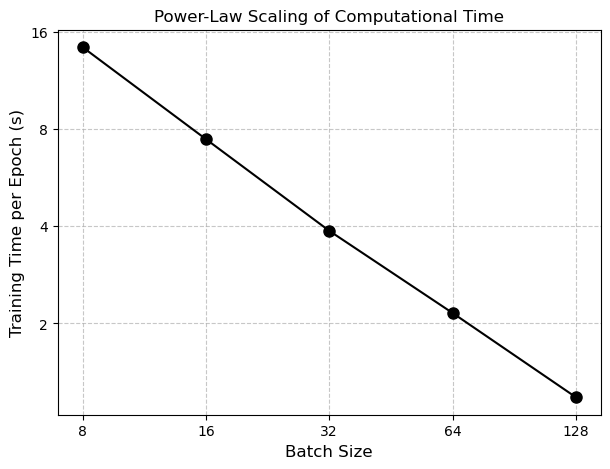

Scaling Exponent (alpha): -0.898


In [4]:
# Power-law fit for computational time
y1 = batch_data_1[1][:,0] / 4096
y2 = batch_data_2[1][:,0] / 512
y_time = np.concatenate((y2, y1))
batch_sizes = np.array([8, 16, 32, 64, 128])

# Plotting time scaling
fig, ax = plt.subplots(figsize=(7,5))
ax.plot(batch_sizes, y_time, marker=".", markersize=16, linestyle="-", color="black")
ax.set_xscale("log", base=2)
ax.set_yscale("log", base=2)
ax.set_xticks(batch_sizes)
ax.set_xticklabels(batch_sizes)
ax.set_yticks([2, 4, 8, 16])
ax.set_yticklabels([2, 4, 8, 16])
ax.set_ylabel("Training Time per Epoch (s)", fontsize=12)
ax.set_xlabel("Batch Size", fontsize=12)
ax.set_title("Power-Law Scaling of Computational Time")
ax.grid(True, linestyle="--", alpha=0.7)
plt.show()

# Extracting the scaling exponent
x_log = np.log2(batch_sizes)
y_log = np.log2(y_time)
m, b = np.polyfit(x_log, y_log, 1)
print(f"Scaling Exponent (alpha): {m:.3f}")

**Observation:** The training time follows a clear power-law scaling with respect to the batch size, with an exponent of $\alpha \approx -0.898$. This nearly linear inverse scaling confirms the theoretical expectation of parallelization efficiency on GPU hardware, before memory transfer bottlenecks dominate.

## 4. Activation Functions: Non-linearities and Gradient Flow
Different activation functions alter the topology of the loss landscape. We compare the empirical error rate $(1 - \text{Accuracy})$ in a log-log space to observe the asymptotic convergence rates.

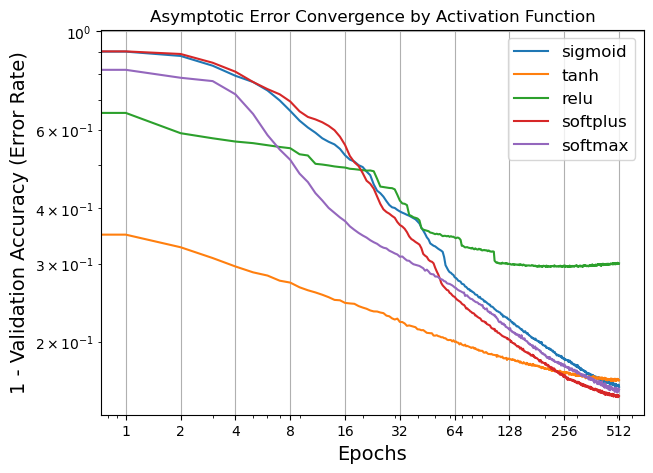

In [5]:
activations = ["sigmoid", "tanh", "relu", "softplus", "softmax"]

plot_activations(
    network_file="exp03_activation_comparison",
    activations=activations,
    measurement="1-vacc",
    y_label="1 - Validation Accuracy (Error Rate)",
    scale="loglog",
    title="Asymptotic Error Convergence by Activation Function",
    data_dir=RESULTS_DIR,
    filename="Activation_Error_Rates",
    output_dir=FIGURES_DIR
)

**Observation:** The `ReLU` and `Softplus` activations exhibit significantly steeper early-time convergence compared to `Sigmoid` or `Tanh`. This visualizes the mitigation of the vanishing gradient problem, allowing the optimizer to traverse the loss landscape much more efficiently during the initial epochs.

## 5. Error Analysis & Systematics (Confusion Matrix)
Finally, we analyze the systematic errors of the optimal model. In physical measurements, distinguishing between systematic and statistical errors is crucial. Here, we map the classification overlap.

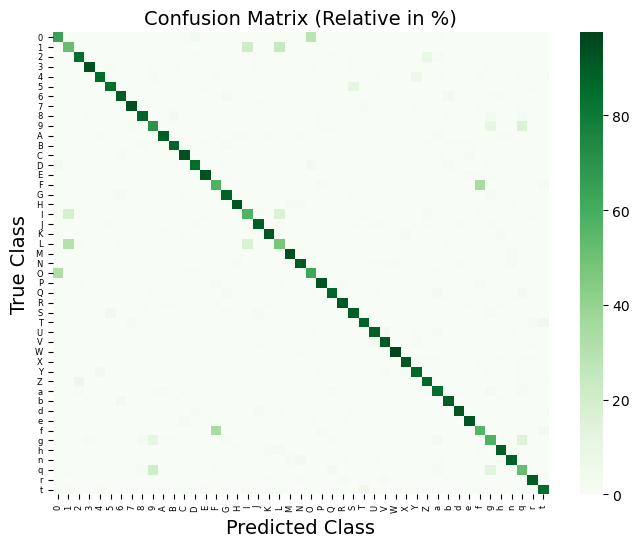

In [6]:
# Load optimal model evaluation
with open(RESULTS_DIR / "exp04_optimal_model_1L.pkl", "rb") as f:
    best_model_data = pickle.load(f)

# Extract the confusion matrix from the saved data structure
cm = best_model_data[3][-1]

plot_confusion_matrix(
    cm=cm,
    symbols=emnist_symbols,
    filename="Optimal_Model_Confusion_Matrix",
    output_dir=FIGURES_DIR
)

**Observation:** The confusion matrix reveals that the remaining error is highly systematic rather than randomly distributed. The network struggles primarily with topologically similar or identical characters (e.g., lowercase `l` vs. uppercase `I`, or `0` vs. `O`). This implies that the model has reached the intrinsic Bayes error rate given the current feature representation, and further scaling of the architecture would not resolve this fundamental ambiguity without contextual data.

## 6. Conclusion
Through systematic variation of hyperparameters, this study demonstrated predictable scaling laws within Neural Networks. The analysis showed:
* A strict capacity saturation point, transitioning from under- to over-parameterization.
* Power-law scaling of GPU computational efficiency governed by batch sizes.
* The superiority of non-saturating gradients (ReLU/Softplus) for rapid optimization.
* Intrinsic dataset limits revealed by systematic topological confusion.

This methodical, physics-inspired approach allows for highly efficient resource allocation in deep learning, moving from empirical guessing to predictable scaling.